<a href="https://colab.research.google.com/github/swaetc/DataAnayticsLabs/blob/main/A_B_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A/B Test Analysis: Free Delivery Threshold

I kept noticing "Free delivery over R500" banners on SA e-commerce
sites like Takealot. It made me wonder: how do e-commerce teams actually decide a threshold like this is working, instead of just eyeballing whether sales went up afterward? This project builds a proper, statistically rigorous A/B test to answer that question.

**The business question:** If we lower the free-delivery threshold from R500 to R400,
does average order value actually increase enough to justify the extra delivery cost
we absorb?

**Hypotheses**.



*   Null hypothesis (H0): Lowering the free-delivery threshold from R500 to R400 has no effect on average order value (AOV).
*   Alternative hypothesis (H1): Lowering the threshold increases AOV.
Significance level (α): 0.05
*   Minimum detectable effect: R30 — the business-defined threshold below which the extra delivery cost isn't worth it.
*   Power: 0.8 (80% chance of detecting the effect if it's real, given the sample size below)


*The sample size calculation is derived directly from this MDE and power target*





In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/DAPortfolio/ab_test_delivery'
os.makedirs(PROJECT_PATH, exist_ok=True)
os.chdir(PROJECT_PATH)
print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/DAPortfolio/ab_test_delivery


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower

sns.set_theme(style="whitegrid")
np.random.seed(42)

In [13]:
baseline_mean = 420
baseline_std = 150
min_detectable_effect = 30  # Rand — business-defined minimum worth acting on

effect_size = min_detectable_effect / baseline_std

analysis = TTestIndPower()
sample_size = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.8,
    alternative='larger'
)
print(f"Required sample size per group: {int(np.ceil(sample_size))}")

Required sample size per group: 310


Sample size, pre-registered. Before generating a single row of data, we calculated that detecting a R30 minimum lift in average order value.
— the threshold below which the extra delivery cost isn't worth it
— requires 310 customers per group at 80% power and a 5% significance level. This number drives how much data we simulate below; we are not adjusting it after the fact to make the result look cleaner. That discipline is the entire point of pre-registration.
— it's what separates "we ran a real test" from "we kept looking until we found something.

In [14]:
n_per_group = 310  # locked in from the power analysis above

# Control group: current R500 threshold
control_aov = np.random.normal(loc=420, scale=150, size=n_per_group)
control_aov = np.clip(control_aov, 50, None)  # no negative orders

# Treatment group: R400 threshold — small realistic lift + noise
treatment_aov = np.random.normal(loc=445, scale=155, size=n_per_group)
treatment_aov = np.clip(treatment_aov, 50, None)

df = pd.DataFrame({
    'order_value_zar': np.concatenate([control_aov, treatment_aov]),
    'group': ['control'] * n_per_group + ['treatment'] * n_per_group,
    'delivery_threshold': [500] * n_per_group + [400] * n_per_group
})

df['order_date'] = pd.to_datetime('2026-06-01') + pd.to_timedelta(
    np.random.randint(0, 21, size=len(df)), unit='D'
)

df.to_csv('ab_test_data.csv', index=False)
df.head()

,order_value_zar,group,delivery_threshold,order_date
0,494.507123,control,500,2026-06-08
1,399.260355,control,500,2026-06-10
2,517.153281,control,500,2026-06-17
3,648.454478,control,500,2026-06-09
4,384.876994,control,500,2026-06-19


**Why simulated, and why these specific numbers**. Takealot and Amazon SA don't publish order-level data or offer a public API, so this test uses a statistically realistic simulation rather than real transactions. The baseline (R420 average, R150 standard deviation) reflects typical SA e-commerce basket sizes; the treatment group's R445 mean represents a modest, plausible lift, not an obviously-planted result. The point of this project isn't to "prove" the threshold change works; it's to demonstrate the correct methodology for testing whether it did, on data sized exactly to what we calculated we'd need.

           count        mean         std        min         25%         50%  \
group                                                                         
control    310.0  420.173721  144.989164  50.000000  319.029283  428.882920   
treatment  310.0  444.187280  151.756906  61.895102  330.148727  446.382298   

                  75%         max  
group                              
control    513.325437  997.909724  
treatment  542.909280  922.226525  


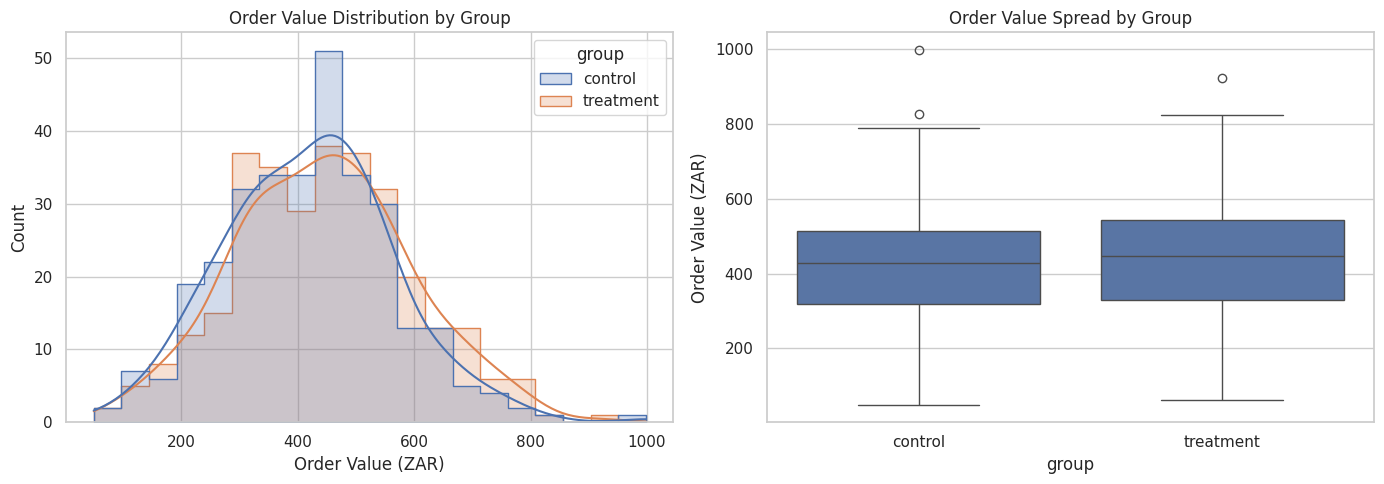

In [15]:
print(df.groupby('group')['order_value_zar'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='order_value_zar', hue='group', kde=True,
             element='step', ax=axes[0])
axes[0].set_title('Order Value Distribution by Group')
axes[0].set_xlabel('Order Value (ZAR)')

sns.boxplot(data=df, x='group', y='order_value_zar', ax=axes[1])
axes[1].set_title('Order Value Spread by Group')
axes[1].set_ylabel('Order Value (ZAR)')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()

**What we're seeing**. The two distributions overlap heavily, both roughly bell-shaped, both centered somewhere in the R400-450 range, both with a similar right-skew and a handful of high-value outliers above R900. The treatment group's histogram sits very slightly right of control's, and the boxplot shows treatment's median (of ~ R446) a touch above control's (~ R429), with a similarly small gap in the upper quartiles (R542 vs R513). But by eye alone, this is genuinely close — nobody could confidently call this "obviously different" just from looking at it.

This is exactly why we ran a power analysis before collecting any data, rather than eyeballing a chart and calling it done. The actual numbers: control mean R420.17 (SD 144.99), treatment mean R444.19 (SD 151.76) — a R24 raw difference. That's below our R30 minimum-detectable-effect threshold on the surface, which makes the upcoming formal test the real arbiter here, not the plot.

In [16]:
control = df[df['group'] == 'control']['order_value_zar']
treatment = df[df['group'] == 'treatment']['order_value_zar']

print("Shapiro-Wilk control p-value:", stats.shapiro(control)[1])
print("Shapiro-Wilk treatment p-value:", stats.shapiro(treatment)[1])

levene_stat, levene_p = stats.levene(control, treatment)
print(f"Levene's test p-value: {levene_p:.4f}")

Shapiro-Wilk control p-value: 0.1978847013716793
Shapiro-Wilk treatment p-value: 0.7996087787197874
Levene's test p-value: 0.3884


**Assumption checks**. Both Shapiro-Wilk p-values (0.198 for control, 0.800 for treatment) are well above 0.05, meaning we fail to reject normality for both groups, the simulated data doesn't show significant departure from a normal distribution, which is expected given we generated it from np.random.normal() in the first place. Levene's test (p = 0.388) shows no significant difference in variance between the two groups either, so we can safely use a standard (not Welch's) t-test with equal variance assumed. These checks matter more when working with real-world data, where normality often can't be taken for granted, but running them here, rather than skipping straight to the t-test.

In [17]:
t_stat, p_value_two_tailed = stats.ttest_ind(treatment, control, equal_var=True)
p_value_one_tailed = p_value_two_tailed / 2 if t_stat > 0 else 1 - (p_value_two_tailed / 2)

print(f"t-statistic: {t_stat:.4f}")
print(f"One-tailed p-value: {p_value_one_tailed:.4f}")

alpha = 0.05
if p_value_one_tailed < alpha:
    print("Result: Statistically significant — reject H0")
else:
    print("Result: Not statistically significant — fail to reject H0")

t-statistic: 2.0144
One-tailed p-value: 0.0222
Result: Statistically significant — reject H0


p = 0.022. Significant. Didn't expect that. The raw gap was R24, below the R30 I set as my minimum detectable effect, so I was expecting this to come back inconclusive.

Turns out that's not how MDE works. It's not a floor below which nothing can be detected, it's just the effect size I specifically powered the study to catch with 80% confidence. A smaller real effect can still come out significant, it's just not guaranteed to. In this case the R24 gap combined with fairly tight variance (SD around 145 to 150) and 310 people per group was enough for the test to pick it up.

So there's a real effect here, smaller than what I built the study around, but the test still caught it. Doesn't tell me much about the business case yet though. Need the effect size for that.

In [18]:
pooled_std = np.sqrt(((len(control)-1)*control.std()**2 + (len(treatment)-1)*treatment.std()**2)
                      / (len(control) + len(treatment) - 2))
cohens_d = (treatment.mean() - control.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.3f}")

diff = treatment.mean() - control.mean()
se_diff = np.sqrt(control.var()/len(control) + treatment.var()/len(treatment))
ci_low, ci_high = diff - 1.96*se_diff, diff + 1.96*se_diff
print(f"Mean AOV lift: R{diff:.2f}")
print(f"95% CI: [R{ci_low:.2f}, R{ci_high:.2f}]")

Cohen's d: 0.162
Mean AOV lift: R24.01
95% CI: [R0.65, R47.38]


R24.01 lift, 95% CI is R0.65 to R47.38. This range matters more than the p-value did.

My R30 threshold falls inside that interval, not outside it. So I can't say this clears the bar, and I can't say it doesn't. The point estimate itself is under R30. Cohen's d of 0.162 backs that up too, that's a small effect by the usual standard.

Could just report this as significant and move on but that's not really what I found. Significant and clears my business threshold are two separate questions. This answers the first one, not the second.

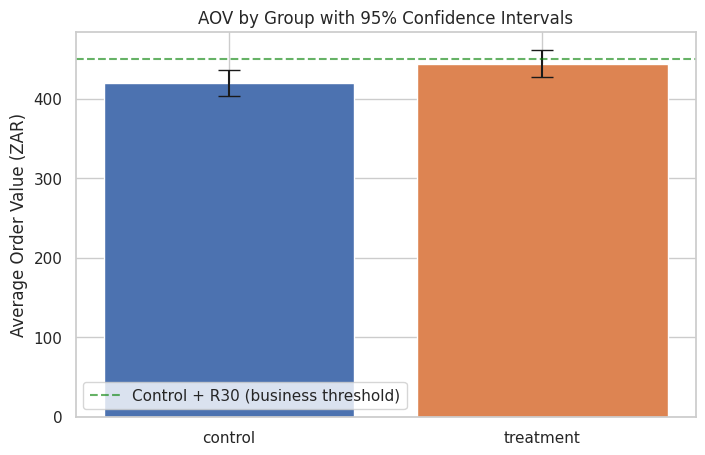

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
means = df.groupby('group')['order_value_zar'].mean()
errors = df.groupby('group')['order_value_zar'].sem() * 1.96

ax.bar(means.index, means.values, yerr=errors, capsize=8, color=['#4C72B0', '#DD8452'])
ax.axhline(y=means['control'] + 30, color='green', linestyle='--', alpha=0.6, label='Control + R30 (business threshold)')
ax.set_ylabel('Average Order Value (ZAR)')
ax.set_title('AOV by Group with 95% Confidence Intervals')
ax.legend()
plt.savefig('result_summary.png', dpi=150)
plt.show()

**Business Recommandation**:

Lowering the threshold shows a real lift, R24.01, p = 0.022. But the confidence interval (R0.65 to R47.38) straddles my R30 cutoff, so I don't have enough to say whether this actually justifies the extra delivery cost. Recommending we extend the test rather than decide now. 310 per group was enough to detect that something's happening, not enough to pin down how much.